<a href="https://colab.research.google.com/github/Brayanbrayan/Image-Segmentation/blob/main/ImageSeg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os

In [2]:
!git config --global user.email "brayannjoroge259@gmail.com"
!git config --global user.name "Brayanbrayan"

In [6]:
!git clone https://github.com/Brayanbrayan/Image-Segmentation.git

Cloning into 'Image-Segmentation'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Total 3 (delta 0), reused 3 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.


In [7]:
cd Image-Segmentation/

/content/Image-Segmentation


In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

In [9]:
def cross_entropy_manual(predictions, targets):
    """
    predictions: (N, C, H, W) — raw logits from the network
    targets:     (N, H, W)    — integer class indices per pixel

    Returns: scalar loss
    """
    # Step 1: convert logits to probabilities
    # softmax across the class dimension (dim=1)
    probs = F.softmax(predictions, dim=1)  # (N, C, H, W)

    # Step 2: gather the probability assigned to the correct class
    # targets needs to be (N, 1, H, W) for gather
    targets_expanded = targets.unsqueeze(1)  # (N, 1, H, W)
    correct_class_probs = probs.gather(dim=1, index=targets_expanded)  # (N, 1, H, W)
    correct_class_probs = correct_class_probs.squeeze(1)  # (N, H, W)

    # Step 3: take log and negate
    loss_per_pixel = -torch.log(correct_class_probs + 1e-8)  # (N, H, W)

    # Step 4: average across ALL pixels
    return loss_per_pixel.mean()


# Verify it matches PyTorch's built-in
def cross_entropy_pytorch(predictions, targets):
    """PyTorch's nn.CrossEntropyLoss handles softmax internally"""
    criterion = nn.CrossEntropyLoss()
    return criterion(predictions, targets)


# Quick sanity check
torch.manual_seed(42)
N, C, H, W = 2, 5, 64, 64  # batch=2, classes=5, image=64x64

fake_predictions = torch.randn(N, C, H, W)
fake_targets = torch.randint(0, C, (N, H, W))

loss_manual = cross_entropy_manual(fake_predictions, fake_targets)
loss_pytorch = cross_entropy_pytorch(fake_predictions, fake_targets)

print(f"Manual CE loss:  {loss_manual.item():.6f}")
print(f"PyTorch CE loss: {loss_pytorch.item():.6f}")
print(f"Difference: {abs(loss_manual.item() - loss_pytorch.item()):.8f}")
# Should be very close to 0

Manual CE loss:  1.994746
PyTorch CE loss: 1.994746
Difference: 0.00000012


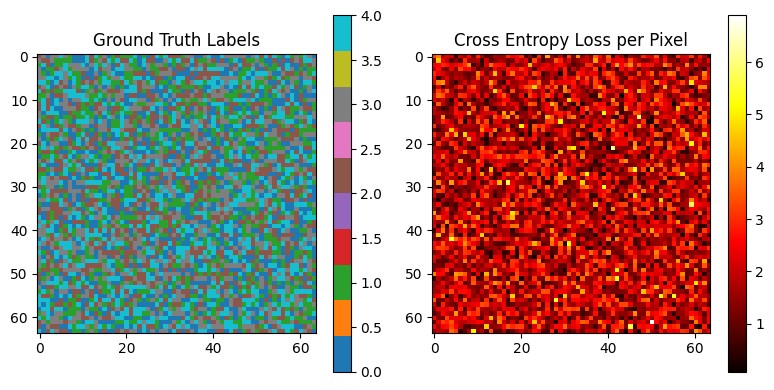

Mean loss: 1.9889
Max loss (hardest pixels): 6.8923
Min loss (easiest pixels): 0.0841


In [10]:
def visualise_ce_loss(predictions, targets, title="Cross Entropy Loss per Pixel"):
    """Show where the loss is high and low across the image"""
    probs = F.softmax(predictions, dim=1)
    targets_expanded = targets.unsqueeze(1)
    correct_class_probs = probs.gather(dim=1, index=targets_expanded).squeeze(1)
    loss_per_pixel = -torch.log(correct_class_probs + 1e-8)

    # Take first image in batch
    loss_map = loss_per_pixel[0].detach().numpy()

    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(targets[0].numpy(), cmap='tab10')
    plt.title("Ground Truth Labels")
    plt.colorbar()

    plt.subplot(1, 2, 2)
    plt.imshow(loss_map, cmap='hot')
    plt.title(title)
    plt.colorbar()
    plt.tight_layout()
    plt.show()

    print(f"Mean loss: {loss_map.mean():.4f}")
    print(f"Max loss (hardest pixels): {loss_map.max():.4f}")
    print(f"Min loss (easiest pixels): {loss_map.min():.4f}")

visualise_ce_loss(fake_predictions, fake_targets)

In [11]:
!git add ImageSeg.ipynb

fatal: pathspec 'ImageSeg.ipynb' did not match any files


In [12]:
!git commit -m "Add notebook"

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [17]:
from google.colab import userdata
token = userdata.get('ImageSeg')
!git push https://{token}@github.com/Brayanbrayan/Image-Segmentation.git

Everything up-to-date


In [19]:
!ls -la /content/Image-Segmentation/

total 16
drwxr-xr-x 3 root root 4096 Jun 13 12:33 .
drwxr-xr-x 1 root root 4096 Jun 13 12:33 ..
drwxr-xr-x 8 root root 4096 Jun 13 12:54 .git
-rw-r--r-- 1 root root   21 Jun 13 12:33 README.md


In [20]:
!cp /path/to/your/ImageSeg.ipynb /content/Image-Segmentation/
!cd /content/Image-Segmentation
!git add ImageSeg.ipynb
!git commit -m "Add image segmentation notebook"
!git push

cp: cannot stat '/path/to/your/ImageSeg.ipynb': No such file or directory
fatal: pathspec 'ImageSeg.ipynb' did not match any files
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
fatal: could not read Username for 'https://github.com': No such device or address


In [21]:
%cd /content/Image-Segmentation

/content/Image-Segmentation


In [24]:
!git add ImageSeg.ipynb

fatal: pathspec 'ImageSeg.ipynb' did not match any files


In [25]:
!pwd

/content/Image-Segmentation
